# **Logistic Regression: The Perceptron Trick**

### **Topic Roadmap**

**1. Dataset Generation**

**2. The Perceptron Trick Implementation**

**3. Scikit-Learn Logistic Regression**

**4. Decision Boundary Comparison**

### **1. Dataset Generation**

Import standard libraries and generate a linearly separable binary classification dataset.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

sns.set_theme(style="whitegrid")

In [2]:
# Generate a binary classification dataset
X, y = make_classification(
    n_samples=100, 
    n_features=2, 
    n_informative=1,
    n_redundant=0,
    n_classes=2, 
    n_clusters_per_class=1, 
    random_state=41,
    hypercube=False,
    class_sep=10
)

### **2. The Perceptron Trick Implementation**

**What this section does**
Implements a classic Perceptron algorithm using a step function. 

**Why it is used**
It demonstrates the foundational logic behind linear classifiers before the introduction of continuous activation functions (like the Sigmoid function used in modern Logistic Regression).

In [3]:
def step_function(z):
    """Returns 1 if z is positive, else 0."""
    return 1 if z > 0 else 0

In [4]:
def perceptron_trick(X, y, learning_rate=0.1, epochs=1000):
    """
    Updates weights iteratively by picking a random sample.
    Weights are only adjusted if the step function misclassifies the point.
    """
    # Insert a column of 1s to account for the intercept (bias) term
    X_with_bias = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X_with_bias.shape[1])
    
    for _ in range(epochs):
        j = np.random.randint(0, X.shape[0])
        y_pred = step_function(np.dot(X_with_bias[j], weights))
        
        # Perceptron weight update rule
        weights = weights + learning_rate * (y[j] - y_pred) * X_with_bias[j]
        
    intercept = weights[0]
    coefficients = weights[1:]
    
    return intercept, coefficients

In [5]:
perceptron_intercept, perceptron_coef = perceptron_trick(X, y)

# Calculate slope (m) and intercept (b) for the decision boundary line: x2 = mx1 + b
m_perceptron = -(perceptron_coef[0] / perceptron_coef[1])
b_perceptron = -(perceptron_intercept / perceptron_coef[1])

### **3. Scikit-Learn Logistic Regression**

Train a production-standard Logistic Regression model to compare its decision boundary against the custom Perceptron.

In [6]:
log_reg = LogisticRegression()
log_reg.fit(X, y)

# Extract slope and intercept for the Logistic Regression boundary
m_logreg = -(log_reg.coef_[0][0] / log_reg.coef_[0][1])
b_logreg = -(log_reg.intercept_[0] / log_reg.coef_[0][1])

### **4. Decision Boundary Comparison**

Plot the dataset alongside the decision boundaries calculated by both algorithms.

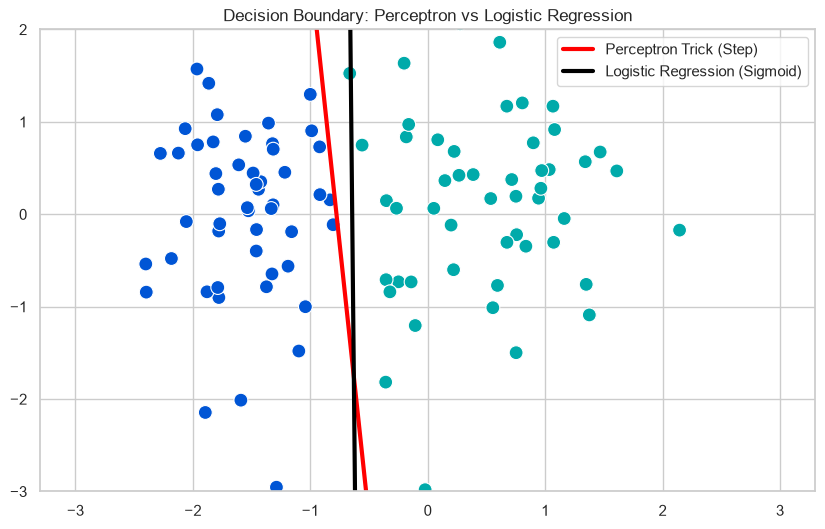

In [7]:
# Generate x-axis values for plotting the lines
x_bounds = np.linspace(-3, 3, 100)

y_bound_perceptron = m_perceptron * x_bounds + b_perceptron
y_bound_logreg = m_logreg * x_bounds + b_logreg

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='winter', s=100, legend=False)

plt.plot(x_bounds, y_bound_perceptron, color='red', linewidth=3, label='Perceptron Trick (Step)')
plt.plot(x_bounds, y_bound_logreg, color='black', linewidth=3, label='Logistic Regression (Sigmoid)')

plt.ylim(-3, 2)
plt.title('Decision Boundary: Perceptron vs Logistic Regression')
plt.legend()
plt.show()

### **Key Revision Notes**

- **Step Function vs. Sigmoid:** The Perceptron algorithm uses a hard step function ($0$ or $1$) to classify points. Logistic Regression uses a Sigmoid function to output continuous probabilities between $0$ and $1$.
- **Weight Updates:** Because of the step function, the Perceptron only updates its weights when an error (misclassification) occurs. Logistic regression updates weights based on gradient descent across the entire probability loss surface.
- **Decision Boundary Mathematics:** The boundary for both linear classifiers is defined by $w_1x_1 + w_2x_2 + b = 0$. By isolating $x_2$, we calculate the slope $m = -(w_1/w_2)$ and the $y$-intercept $b_{plot} = -(b/w_2)$.